In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D,Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [2]:
fashion_mnist = datasets.fashion_mnist
(X_train,y_train),(X_test,y_test) = fashion_mnist.load_data()

In [3]:
X_train = X_train.reshape((60000,28,28,1))
X_test = X_test.reshape((10000,28,28,1))

In [4]:
X_train = X_train/255.0
X_test = X_test/255.0

In [5]:
model = Sequential()
model.add(Input(shape=(28,28,1)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 64)        640       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 13, 13, 64)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 11, 11, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 5, 5, 64)         0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 3, 3, 64)          36928     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 1, 1, 64)         0

In [6]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [7]:
h=model.fit(X_train,y_train,epochs=5)

Epoch 1/5
1875/1875 [==============================] - 8s 3ms/step - loss: 0.5843 - accuracy: 0.7854
Epoch 2/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.3933 - accuracy: 0.8562
Epoch 3/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.3360 - accuracy: 0.8759
Epoch 4/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2979 - accuracy: 0.8895
Epoch 5/5
1875/1875 [==============================] - 5s 3ms/step - loss: 0.2732 - accuracy: 0.8978


In [8]:
loss,acc = model.evaluate(X_test,y_test)
print('정확도 :',acc*100)

313/313 [==============================] - 1s 2ms/step - loss: 0.3183 - accuracy: 0.8843
정확도 : 88.42999935150146


# C 뭐시기 이미지 분류

In [9]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import datasets
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D,Flatten
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [10]:
cifar_10 = datasets.cifar10
(X_train,y_train),(X_test,y_test) = cifar_10.load_data()

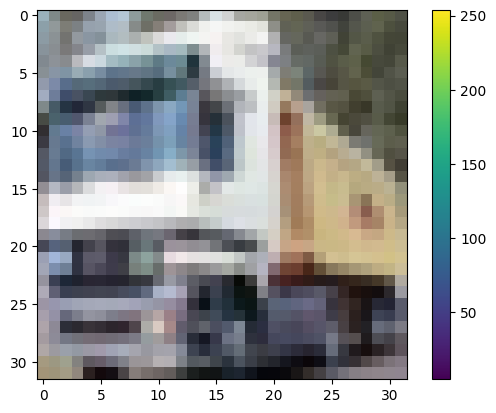

In [11]:
plt.figure()
plt.imshow(X_train[1])
plt.colorbar()

In [12]:
X_train = X_train/255.0
X_test = X_test/255.0

In [13]:
model = Sequential()
model.add(Input(shape=(32,32,3)))

model.add(Conv2D(32, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_3 (MaxPooling  (None, 15, 15, 32)       0         
 2D)                                                             
                                                                 
 conv2d_4 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 6, 6, 64)         0         
 2D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 2304)              0         
                                                                 
 dense_2 (Dense)             (None, 64)               

In [14]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [15]:
h=model.fit(X_train,y_train,epochs=10, batch_size=32,verbose=1,validation_split=0.3)

Epoch 1/10
1094/1094 [==============================] - 5s 4ms/step - loss: 1.5376 - accuracy: 0.4437 - val_loss: 1.2784 - val_accuracy: 0.5573
Epoch 2/10
1094/1094 [==============================] - 4s 4ms/step - loss: 1.1768 - accuracy: 0.5819 - val_loss: 1.1252 - val_accuracy: 0.6025
Epoch 3/10
1094/1094 [==============================] - 4s 4ms/step - loss: 1.0394 - accuracy: 0.6374 - val_loss: 1.0826 - val_accuracy: 0.6280
Epoch 4/10
1094/1094 [==============================] - 4s 4ms/step - loss: 0.9508 - accuracy: 0.6665 - val_loss: 0.9988 - val_accuracy: 0.6540
Epoch 5/10
1094/1094 [==============================] - 4s 4ms/step - loss: 0.8793 - accuracy: 0.6922 - val_loss: 0.9842 - val_accuracy: 0.6585
Epoch 6/10
1094/1094 [==============================] - 4s 4ms/step - loss: 0.8158 - accuracy: 0.7141 - val_loss: 0.9716 - val_accuracy: 0.6671
Epoch 7/10
1094/1094 [==============================] - 4s 4ms/step - loss: 0.7573 - accuracy: 0.7359 - val_loss: 0.9893 - val_accuracy:

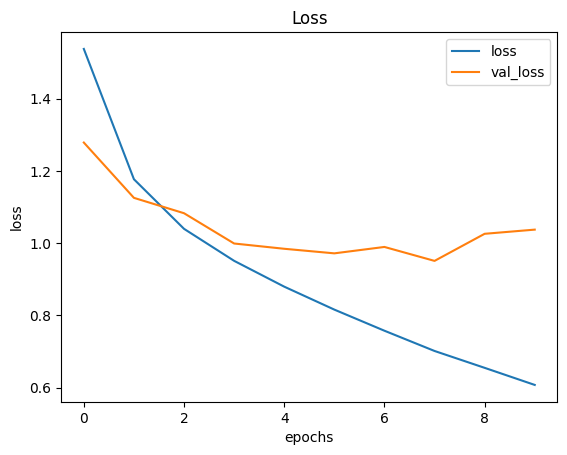

In [16]:
plt.plot(h.history['loss'])
plt.plot(h.history['val_loss'])
plt.title('Loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['loss','val_loss'])
plt.show()

In [17]:
loss,acc = model.evaluate(X_test,y_test)
print('정확도 :',acc*100)

313/313 [==============================] - 1s 3ms/step - loss: 1.0370 - accuracy: 0.6572
정확도 : 65.71999788284302


313/313 [==============================] - 0s 1ms/step
정답 :  cat
예측값 : cat


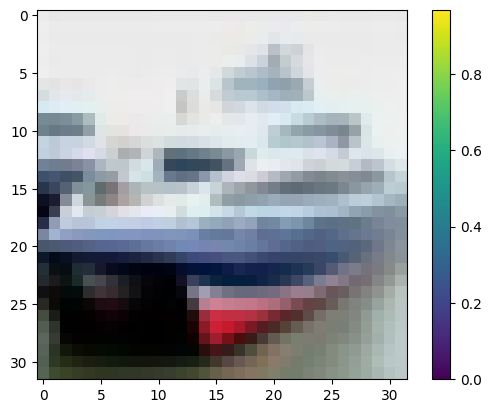

In [18]:
class_name = ['airplane','audomobile','bird','cat','deer','dog','frog','horse','ship','truck']
plt.figure()
plt.imshow(X_test[1])
plt.colorbar()
y_pred=model.predict(X_test)
print('정답 : ',class_name[y_test[0][0]])
print('예측값 :',class_name[np.argmax(y_pred[0])])

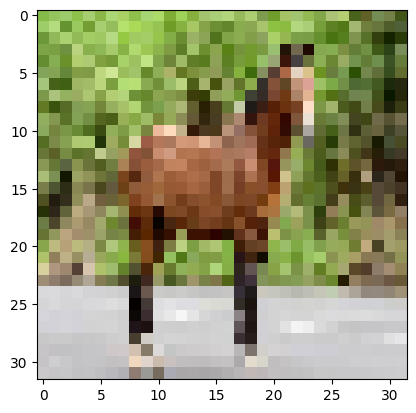

1/1 [==============================] - 0s 66ms/step
[[0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]]
예측값 : horse


In [19]:
import cv2 as cv

image=cv.imread('./test/horse.jpg',cv.IMREAD_COLOR)
image=cv.cvtColor(image,cv.COLOR_BGR2RGB)
image=cv.resize(image,(32,32))
iamge=image/255.0

input_data = image.reshape(1,32,32,3)

plt.imshow(image)
plt.show()
pred=model.predict(input_data)
print(pred)
print('예측값 :',class_name[np.argmax(pred)])